# Autoscaling for MongoDB

## Horizontal Scaling by Adding Replicas (CPU Utilization Triggered)

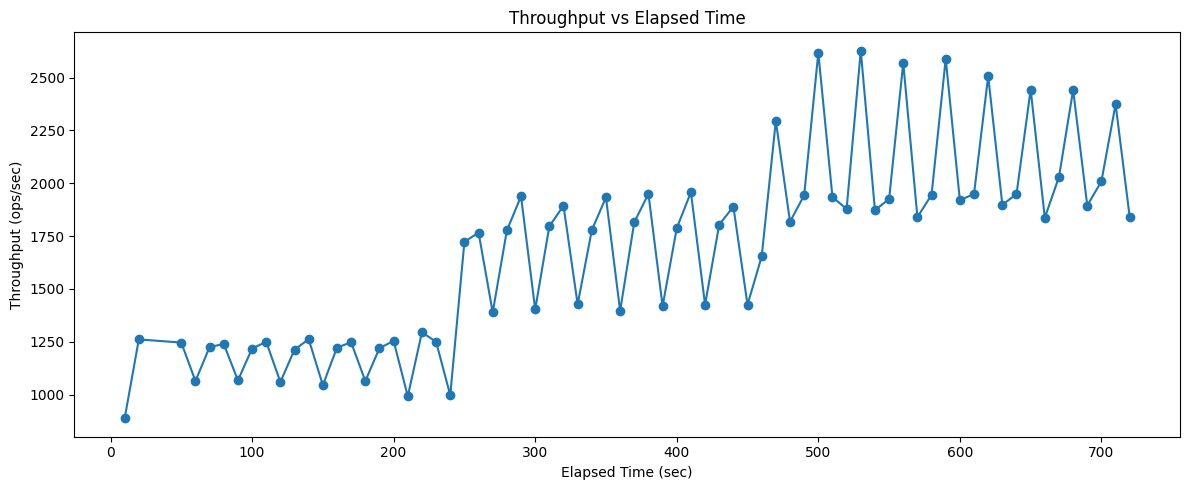

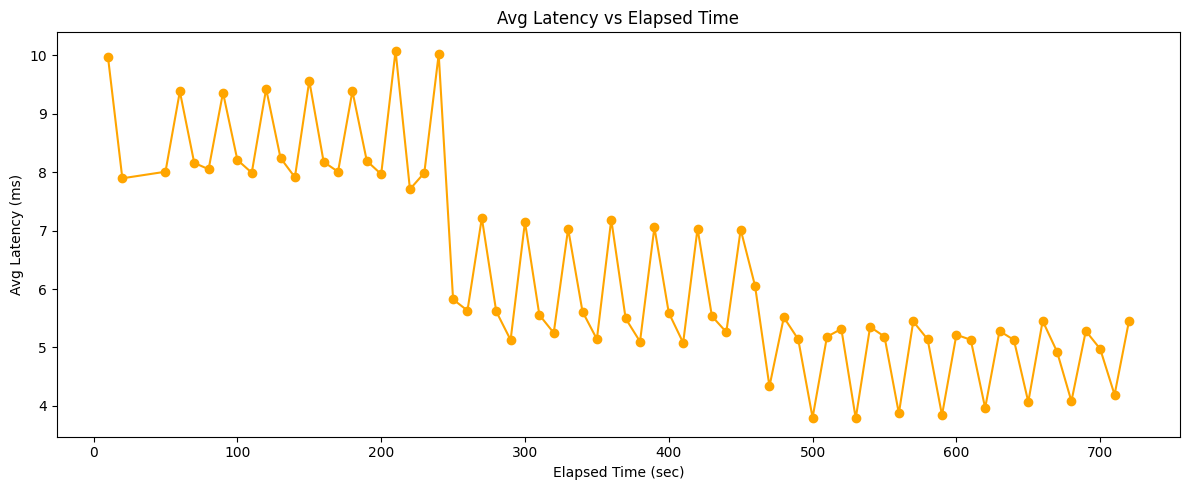

In [4]:
import matplotlib.pyplot as plt
import re

times = []
throughputs = []
latencies = []

with open('cpu_logs/t10_cpu.log') as f:
    for line in f:
        if line.startswith('#OUTLIER'):
            continue
        # Match lines with elapsed sec, ops/sec, and Avg latency
        match = re.search(r'(\d+) sec:.*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
        if match:
            elapsed_sec = int(match.group(1))
            times.append(elapsed_sec)
            throughputs.append(float(match.group(2)))
            latencies.append(float(match.group(3)) / 1000)

# Plot throughput vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, throughputs, marker='o')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Throughput (ops/sec)')
plt.title('Throughput vs Elapsed Time')
plt.tight_layout()
plt.show()

# Plot avg latency vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, latencies, marker='o', color='orange')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Avg Latency (ms)')
plt.title('Avg Latency vs Elapsed Time')
plt.tight_layout()
plt.show()

## Horizontal Scaling by Adding Replicas (IOWait Triggered)

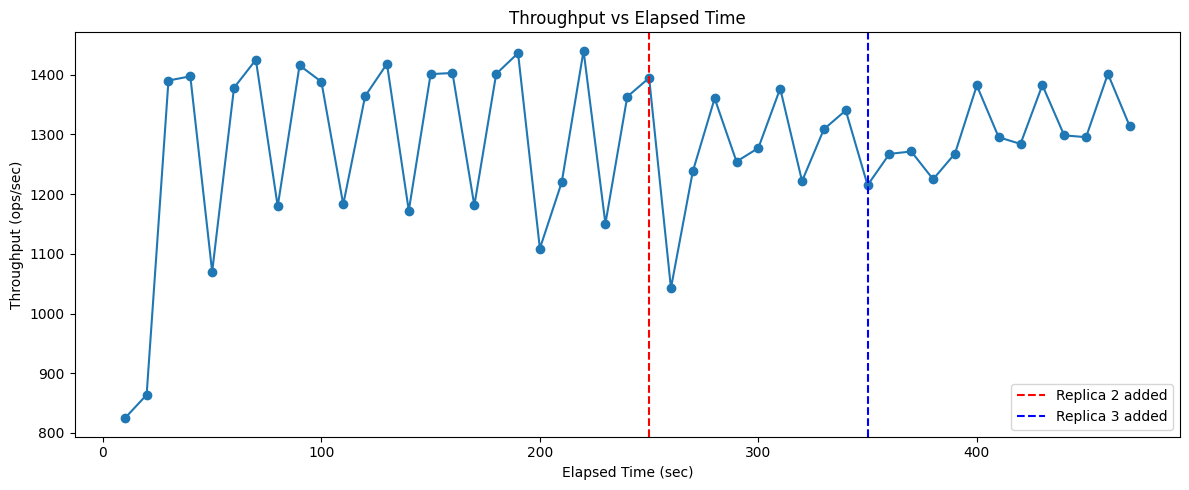

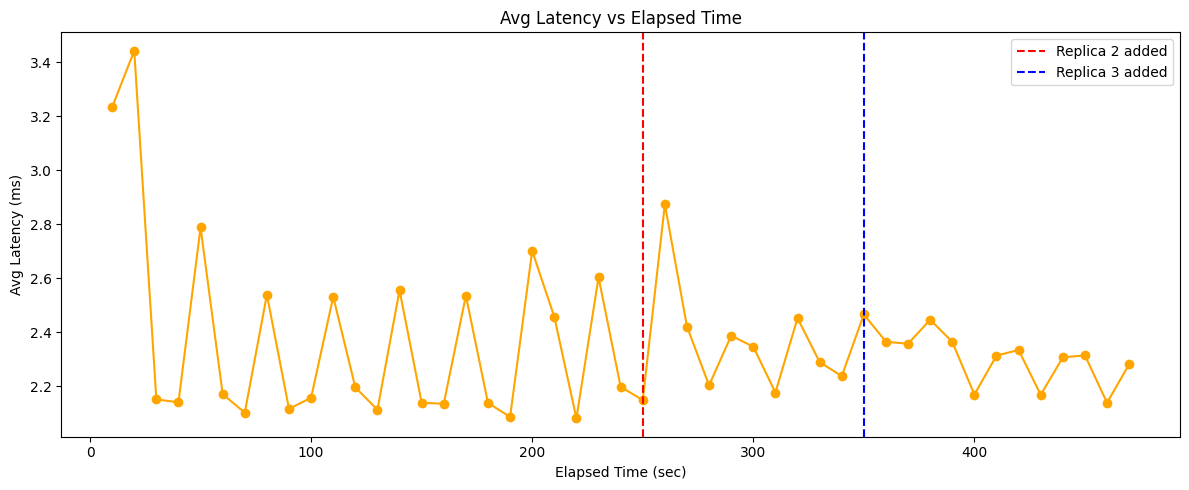

In [3]:
import matplotlib.pyplot as plt
import re

times = []
throughputs = []
latencies = []

with open('iowait_logs/t3_iowait.log') as f:
    for line in f:
        if line.startswith('#OUTLIER'):
            continue
        # Match lines with elapsed sec, ops/sec, and Avg latency
        match = re.search(r'(\d+) sec:.*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
        if match:
            elapsed_sec = int(match.group(1))
            times.append(elapsed_sec)
            throughputs.append(float(match.group(2)))
            latencies.append(float(match.group(3)) / 1000)

# Plot throughput vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, throughputs, marker='o')
plt.axvline(x=250, color='red', linestyle='--', label='Replica 2 added')
plt.axvline(x=350, color='blue', linestyle='--', label='Replica 3 added')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Throughput (ops/sec)')
plt.title('Throughput vs Elapsed Time')
plt.legend()
plt.tight_layout()
plt.show()

# Plot avg latency vs elapsed time
plt.figure(figsize=(12, 5))
plt.plot(times, latencies, marker='o', color='orange')
plt.axvline(x=250, color='red', linestyle='--', label='Replica 2 added')
plt.axvline(x=350, color='blue', linestyle='--', label='Replica 3 added')
plt.xlabel('Elapsed Time (sec)')
plt.ylabel('Avg Latency (ms)')
plt.title('Avg Latency vs Elapsed Time')
plt.legend()
plt.tight_layout()
plt.show()

## Mongos Autoscaler

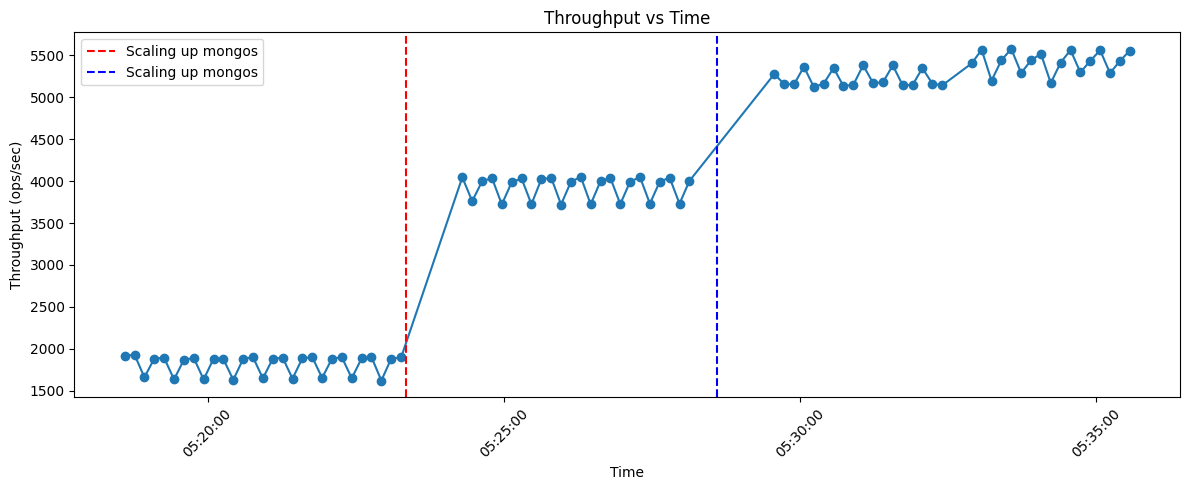

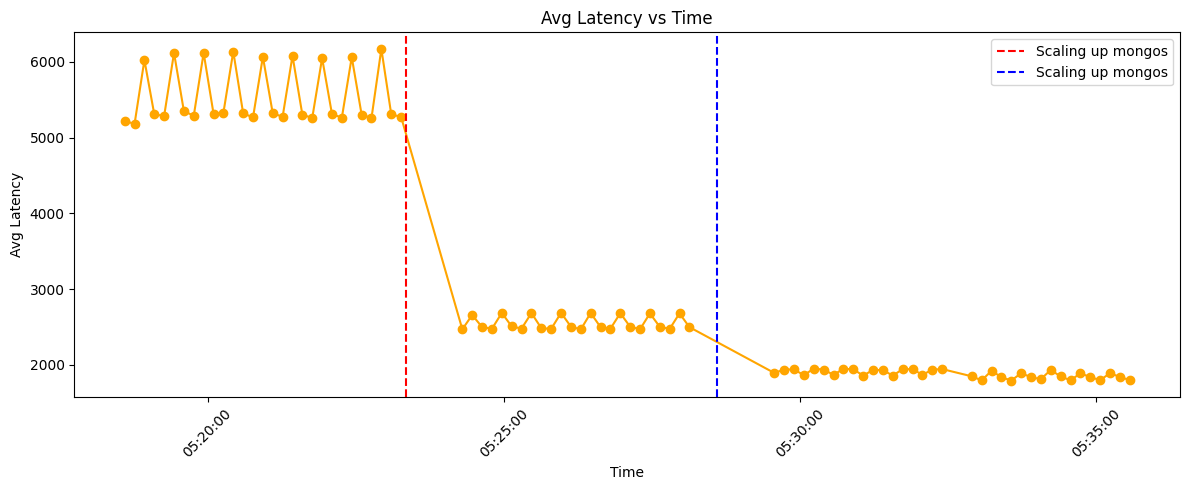

In [48]:
from pathlib import Path
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random

log_dir = Path('mongos_logs')
files = list(log_dir.glob('*.log'))
files.sort()

times = []
throughputs = []
latencies = []

for f in files:
    with f.open() as file:
        for line in file:
            if line.startswith('#OUTLIER'):
                continue
            match = re.search(r' (\d{2}:\d{2}:\d{2}).*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
            if match:
                times.append(datetime.strptime(match.group(1), '%H:%M:%S'))
                throughputs.append(float(match.group(2)))
                latencies.append(float(match.group(3)))

highlight_times = [
    (datetime.strptime('05:23:21', '%H:%M:%S'), "Scaling up mongos", 'red'),
    (datetime.strptime('05:28:36', '%H:%M:%S'), "Scaling up mongos", 'blue'),
]

# Plot throughput vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, throughputs, marker='o')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Throughput (ops/sec)')
ax.set_title('Throughput vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot latency vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, latencies, marker='o', color='orange')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Avg Latency')
ax.set_title('Avg Latency vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Mongod Autoscaler

[3108.57, 3123.98, 3585.79, 3125.3, 3142.53, 3552.33, 3134.15, 3126.4, 3601.2, 3123.85, 3127.29, 3597.61, 3137.46, 3119.93, 3568.64, 3136.03, 3315.24, 3836.07, 3132.67, 3291.01, 3869.17, 3286.04, 3233.49, 3693.77, 3289.13, 3314.51, 3833.34, 3155.74, 3301.9, 3831.8, 3321.83, 3331.03, 3335.01, 3358.98, 3570.44, 3370.79, 3313.81, 3738.73, 3348.17, 3176.79, 3743.38, 3407.87, 3330.89, 3613.67, 3366.37, 3373.28, 3740.1, 3379.05, 3151.65, 3726.06, 3392.38, 3339.71, 3655.83, 3306.94, 3322.33, 3743.86, 3402.93, 3183.4, 3751.28, 3407.96, 3299.96, 3699.61, 3260.44, 3322.7, 3734.82, 3372.16, 3354.76, 3802.74, 3132.08, 3298.93, 3842.09, 3300.29, 3285.59, 3612.72, 3303.84, 3323.16, 3823.59, 3201.71, 3231.49, 3834.59, 3280.77, 3296.38, 3592.22, 3303.67, 3301.17, 3816.56, 3257.84, 3194.88, 3834.98, 3305.87, 3324.1, 3614.15, 3289.37, 3337.67, 3862.9, 3292.73, 3154.43, 3921.91, 3314.84, 3314.5, 3380.41, 3330.47, 3269.84, 3704.62, 3337.48, 3920.6, 3947.13, 3294.01, 4284.41, 2067.28, 1894.09, 2080.9, 2024

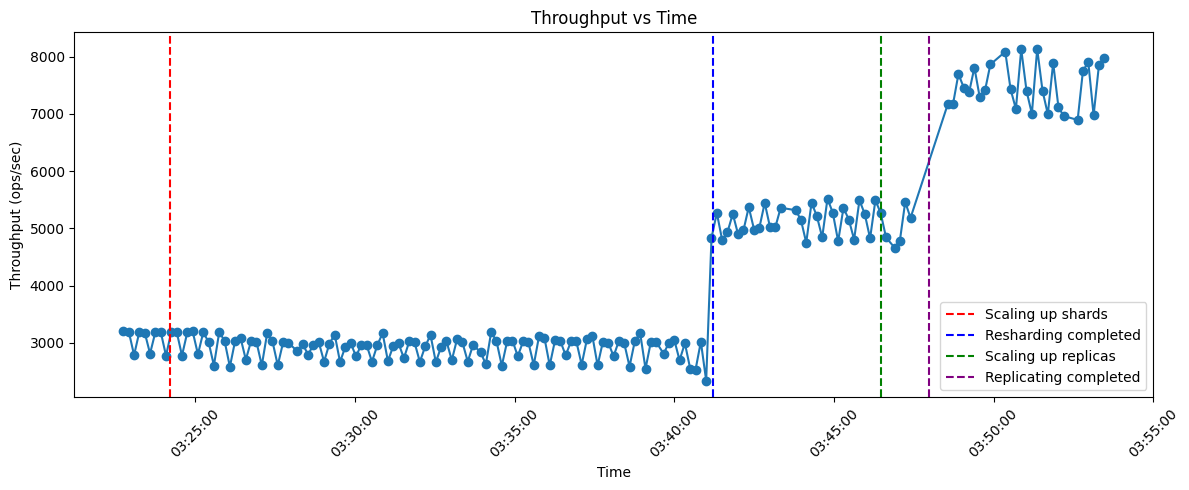

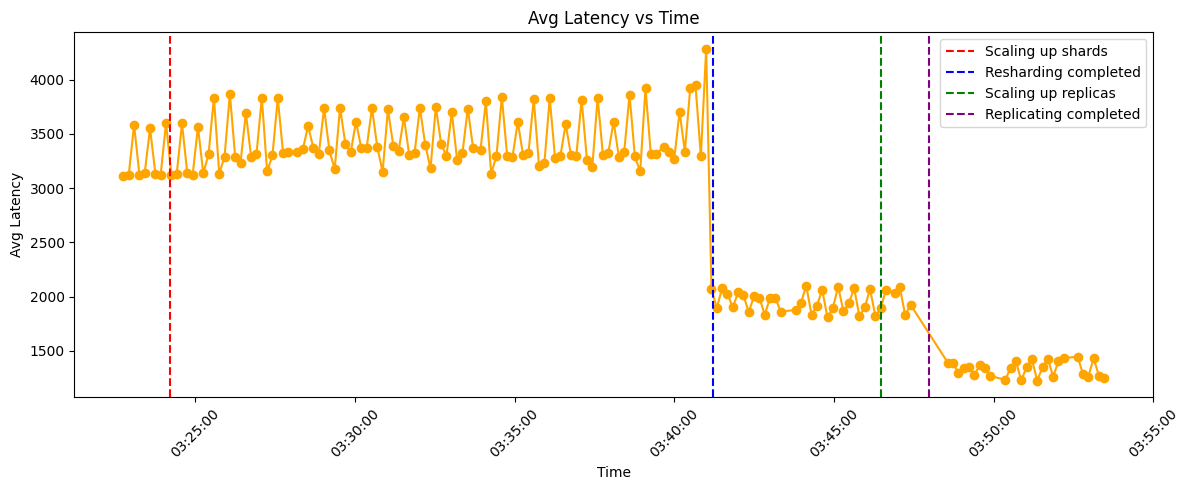

In [47]:
from pathlib import Path
import re
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

log_dir = Path('mongod_logs')
files = list(log_dir.glob('*.log'))
files.sort()

times = []
throughputs = []
latencies = []

for f in files:
    with f.open() as file:
        for line in file:
            if line.startswith('#OUTLIER'):
                continue
            match = re.search(r' (\d{2}:\d{2}:\d{2}).*? ([\d.]+) current ops/sec;.*Avg=([\d.]+)', line)
            if match:
                times.append(datetime.strptime(match.group(1), '%H:%M:%S'))
                throughputs.append(float(match.group(2)))
                latencies.append(float(match.group(3)))

highlight_times = [
    (datetime.strptime('03:24:12', '%H:%M:%S'), "Scaling up shards", 'red'),
    (datetime.strptime('03:41:13', '%H:%M:%S'), "Resharding completed", 'blue'),
    (datetime.strptime('03:46:28', '%H:%M:%S'), "Scaling up replicas ", 'green'),
    (datetime.strptime('03:47:58', '%H:%M:%S'), "Replicating completed", 'purple'),
]

print(latencies)

# Plot throughput vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, throughputs, marker='o')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Throughput (ops/sec)')
ax.set_title('Throughput vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot latency vs time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times, latencies, marker='o', color='orange')
for ht, label, color in highlight_times:
    ax.axvline(x=ht, color=color, linestyle='--', label=label)
ax.set_xlabel('Time')
ax.set_ylabel('Avg Latency')
ax.set_title('Avg Latency vs Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()